In [5]:
from google.colab import files
uploaded = files.upload()


Saving job_postings_muskan.csv to job_postings_muskan.csv


In [6]:
import pandas as pd

df = pd.read_csv("job_postings_muskan.csv")
df.head()


,job_title,job_description,location,role_group,skills
0,Data Analyst,"We are looking for a Data Analyst with strong skills in SQL, Excel, Tableau, and Python for data cleaning and dashboarding.",USA,Data Analyst,"SQL, Excel, Tableau, Python"
1,Data Scientist,"Seeking a Data Scientist with experience in Python, ML models, NLP techniques, and cloud platforms like AWS or Azure.",Canada,Data Scientist,"Python, Machine Learning, NLP, AWS, Azure"
2,Machine Learning Engineer,"ML Engineer needed with expertise in model deployment, TensorFlow, PyTorch, MLOps, Kubernetes, and Python.",USA,ML Engineer,"TensorFlow, PyTorch, Kubernetes, MLOps, Python"
3,Business Analyst,"Business Analyst role requiring strong communication, requirement gathering, documentation, SQL, and stakeholder management.",UK,Business Analyst,"Communication, SQL, Documentation, Stakeholder Management"
4,Data Analyst,"Analyze datasets using Python, PowerBI, Excel; create insights and automate reporting dashboards.",India,Data Analyst,"Python, PowerBI, Excel"


In [7]:
# Quick peek at the data
print("Shape:", df.shape)
display(df.head())

print("\nColumns:\n", df.columns.tolist())

print("\nInfo:")
df.info()

print("\nMissing values per column:")
print(df.isna().sum())


Shape: (6, 5)


,job_title,job_description,location,role_group,skills
0,Data Analyst,"We are looking for a Data Analyst with strong skills in SQL, Excel, Tableau, and Python for data cleaning and dashboarding.",USA,Data Analyst,"SQL, Excel, Tableau, Python"
1,Data Scientist,"Seeking a Data Scientist with experience in Python, ML models, NLP techniques, and cloud platforms like AWS or Azure.",Canada,Data Scientist,"Python, Machine Learning, NLP, AWS, Azure"
2,Machine Learning Engineer,"ML Engineer needed with expertise in model deployment, TensorFlow, PyTorch, MLOps, Kubernetes, and Python.",USA,ML Engineer,"TensorFlow, PyTorch, Kubernetes, MLOps, Python"
3,Business Analyst,"Business Analyst role requiring strong communication, requirement gathering, documentation, SQL, and stakeholder management.",UK,Business Analyst,"Communication, SQL, Documentation, Stakeholder Management"
4,Data Analyst,"Analyze datasets using Python, PowerBI, Excel; create insights and automate reporting dashboards.",India,Data Analyst,"Python, PowerBI, Excel"



Columns:
 ['job_title', 'job_description', 'location', 'role_group', 'skills']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        6 non-null      object
 1   job_description  6 non-null      object
 2   location         6 non-null      object
 3   role_group       6 non-null      object
 4   skills           6 non-null      object
dtypes: object(5)
memory usage: 372.0+ bytes

Missing values per column:
job_title          0
job_description    0
location           0
role_group         0
skills             0
dtype: int64


Role counts:
role_group
Data Analyst        2
Data Scientist      2
ML Engineer         1
Business Analyst    1
Name: count, dtype: int64


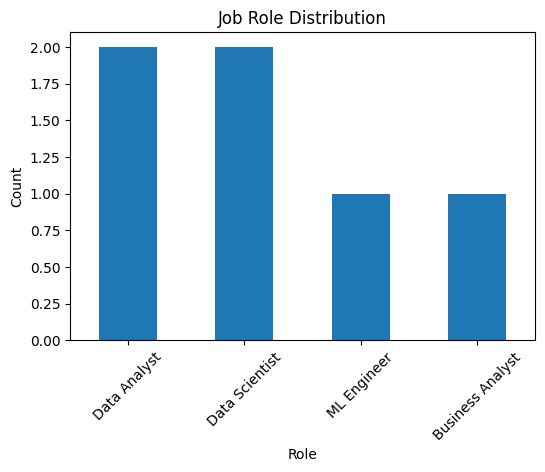


Location counts:
location
USA       3
Canada    1
UK        1
India     1
Name: count, dtype: int64


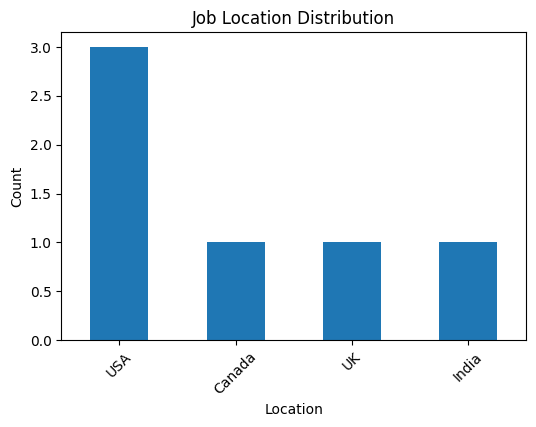

In [8]:
import matplotlib.pyplot as plt

# Role distribution
print("Role counts:")
print(df["role_group"].value_counts())

plt.figure(figsize=(6,4))
df["role_group"].value_counts().plot(kind="bar")
plt.title("Job Role Distribution")
plt.xlabel("Role")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Location distribution
print("\nLocation counts:")
print(df["location"].value_counts())

plt.figure(figsize=(6,4))
df["location"].value_counts().plot(kind="bar")
plt.title("Job Location Distribution")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [9]:
from collections import Counter

def split_skills(s):
    # handle NaN safely
    return [skill.strip() for skill in str(s).split(",") if skill.strip()]

# New column with list of skills
df["skills_list"] = df["skills"].apply(split_skills)

df[["job_title", "skills", "skills_list"]]


,job_title,skills,skills_list
0,Data Analyst,"SQL, Excel, Tableau, Python","[SQL, Excel, Tableau, Python]"
1,Data Scientist,"Python, Machine Learning, NLP, AWS, Azure","[Python, Machine Learning, NLP, AWS, Azure]"
2,Machine Learning Engineer,"TensorFlow, PyTorch, Kubernetes, MLOps, Python","[TensorFlow, PyTorch, Kubernetes, MLOps, Python]"
3,Business Analyst,"Communication, SQL, Documentation, Stakeholder Management","[Communication, SQL, Documentation, Stakeholder Management]"
4,Data Analyst,"Python, PowerBI, Excel","[Python, PowerBI, Excel]"
5,Data Scientist,"Python, NLP, Machine Learning, Big Data","[Python, NLP, Machine Learning, Big Data]"


In [10]:
# Flatten all skills into one big list
all_skills = []
for skill_list in df["skills_list"]:
    all_skills.extend(skill_list)

skill_counts = Counter(all_skills)
print("Top 10 skills:\n", skill_counts.most_common(10))


Top 10 skills:
 [('Python', 5), ('SQL', 2), ('Excel', 2), ('Machine Learning', 2), ('NLP', 2), ('Tableau', 1), ('AWS', 1), ('Azure', 1), ('TensorFlow', 1), ('PyTorch', 1)]


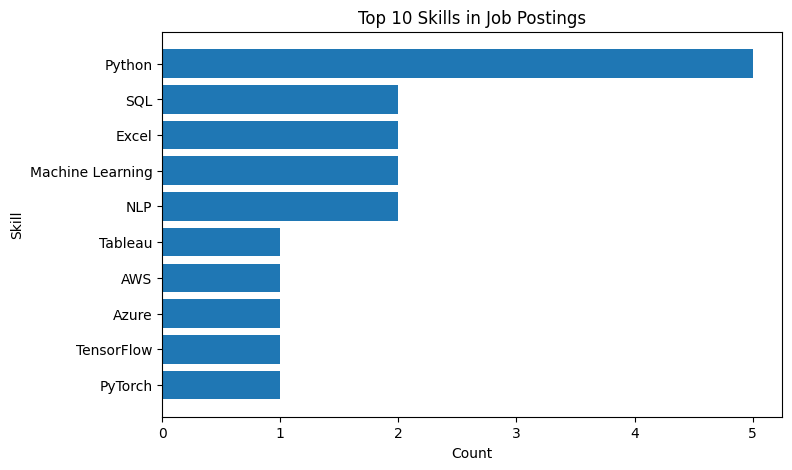

In [11]:
top_n = 10
top_skills = skill_counts.most_common(top_n)

skills = [s[0] for s in top_skills]
freqs = [s[1] for s in top_skills]

plt.figure(figsize=(8,5))
plt.barh(skills, freqs)
plt.gca().invert_yaxis()
plt.title(f"Top {top_n} Skills in Job Postings")
plt.xlabel("Count")
plt.ylabel("Skill")
plt.show()


In [12]:
rows = []

for _, row in df.iterrows():
    role = row["role_group"]
    for skill in row["skills_list"]:
        rows.append({"role_group": role, "skill": skill})

skill_role_df = pd.DataFrame(rows)

# Pivot: skill vs role
skill_pivot = skill_role_df.pivot_table(
    index="skill",
    columns="role_group",
    aggfunc="size",
    fill_value=0
)

# Sort by total occurrences
skill_pivot["total"] = skill_pivot.sum(axis=1)
skill_pivot = skill_pivot.sort_values("total", ascending=False)

skill_pivot.head(15)


role_group,Business Analyst,Data Analyst,Data Scientist,ML Engineer,total
skill,,,,,
Python,0,2,2,1,5
SQL,1,1,0,0,2
Machine Learning,0,0,2,0,2
NLP,0,0,2,0,2
Excel,0,2,0,0,2
AWS,0,0,1,0,1
Documentation,1,0,0,0,1
Azure,0,0,1,0,1
Big Data,0,0,1,0,1


In [13]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [14]:
def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove special chars
    text = re.sub(r"[^a-zA-Z ]", " ", text)

    # Tokenize
    words = text.split()

    # Remove stopwords + lemmatize
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(words)

df["clean_description"] = df["job_description"].apply(clean_text)

df[["job_description", "clean_description"]].head()


,job_description,clean_description
0,"We are looking for a Data Analyst with strong skills in SQL, Excel, Tableau, and Python for data cleaning and dashboarding.",looking data analyst strong skill sql excel tableau python data cleaning dashboarding
1,"Seeking a Data Scientist with experience in Python, ML models, NLP techniques, and cloud platforms like AWS or Azure.",seeking data scientist experience python ml model nlp technique cloud platform like aws azure
2,"ML Engineer needed with expertise in model deployment, TensorFlow, PyTorch, MLOps, Kubernetes, and Python.",ml engineer needed expertise model deployment tensorflow pytorch mlops kubernetes python
3,"Business Analyst role requiring strong communication, requirement gathering, documentation, SQL, and stakeholder management.",business analyst role requiring strong communication requirement gathering documentation sql stakeholder management
4,"Analyze datasets using Python, PowerBI, Excel; create insights and automate reporting dashboards.",analyze datasets using python powerbi excel create insight automate reporting dashboard


In [15]:
from collections import Counter

# Combine all job descriptions into one big text
all_words = " ".join(df["clean_description"]).split()

word_freq = Counter(all_words).most_common(20)
word_freq


[('data', 4),
 ('python', 4),
 ('model', 3),
 ('analyst', 2),
 ('strong', 2),
 ('sql', 2),
 ('excel', 2),
 ('ml', 2),
 ('nlp', 2),
 ('looking', 1),
 ('skill', 1),
 ('tableau', 1),
 ('cleaning', 1),
 ('dashboarding', 1),
 ('seeking', 1),
 ('scientist', 1),
 ('experience', 1),
 ('technique', 1),
 ('cloud', 1),
 ('platform', 1)]

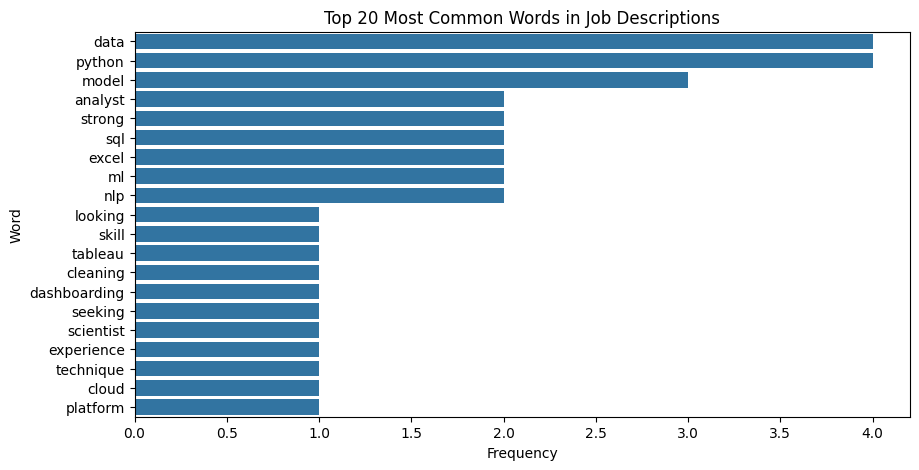

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

words = [w[0] for w in word_freq]
counts = [w[1] for w in word_freq]

plt.figure(figsize=(10,5))
sns.barplot(x=counts, y=words)
plt.title("Top 20 Most Common Words in Job Descriptions")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()


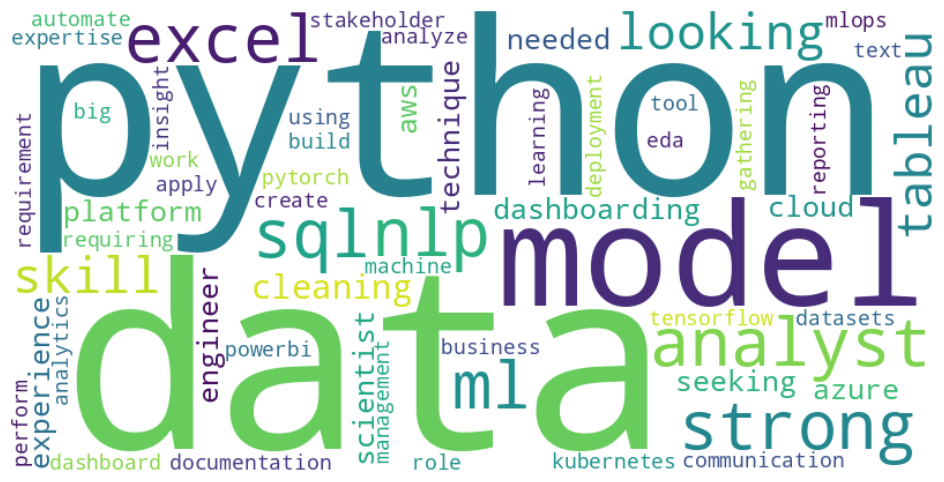

In [17]:
!pip install wordcloud
from wordcloud import WordCloud

text = " ".join(df["clean_description"])
wc = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# TF-IDF with unigrams + bigrams
tfidf = TfidfVectorizer(
    max_df=0.8,         # ignore terms that appear in >80% of docs
    min_df=1,           # keep terms that appear in at least 1 doc
    ngram_range=(1, 2), # unigrams + bigrams
    max_features=50     # limit to top 50 features
)

X_tfidf = tfidf.fit_transform(df["clean_description"])
feature_names = np.array(tfidf.get_feature_names_out())

X_tfidf.shape


(6, 50)

In [19]:
# Average TF-IDF score per term
mean_tfidf = X_tfidf.mean(axis=0).A1
top_n = 20

top_indices = mean_tfidf.argsort()[::-1][:top_n]
top_terms = feature_names[top_indices]
top_scores = mean_tfidf[top_indices]

for term, score in zip(top_terms, top_scores):
    print(f"{term:25s} {score:.4f}")


data                      0.1439
python                    0.1353
model                     0.1160
ml                        0.0955
excel                     0.0916
sql                       0.0888
analyst                   0.0888
strong                    0.0888
nlp                       0.0838
expertise                 0.0654
deployment tensorflow     0.0654
deployment                0.0654
engineer needed           0.0654
engineer                  0.0654
excel create              0.0588
automate reporting        0.0588
automate                  0.0588
datasets                  0.0588
analyze                   0.0588
analyze datasets          0.0588


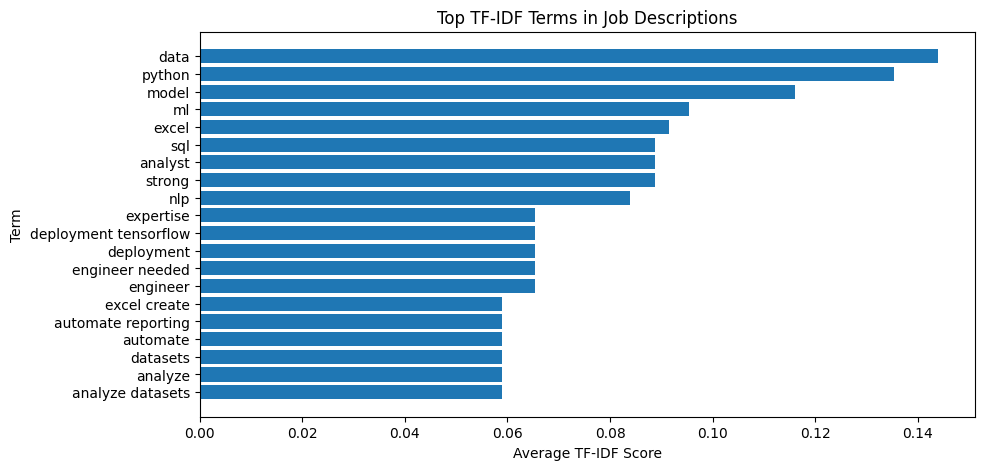

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(top_terms[::-1], top_scores[::-1])
plt.title("Top TF-IDF Terms in Job Descriptions")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Term")
plt.show()


In [21]:
# Combine all descriptions for each role into one big document per role
role_text = df.groupby("role_group")["clean_description"].apply(lambda x: " ".join(x))
role_text


,clean_description
role_group,
Business Analyst,business analyst role requiring strong communication requirement gathering documentation sql stakeholder management
Data Analyst,looking data analyst strong skill sql excel tableau python data cleaning dashboarding analyze datasets using python powerbi excel create insight automate reporting dashboard
Data Scientist,seeking data scientist experience python ml model nlp technique cloud platform like aws azure build machine learning model perform eda work big data tool apply nlp text analytics
ML Engineer,ml engineer needed expertise model deployment tensorflow pytorch mlops kubernetes python


In [22]:
def top_terms_for_role(text_series, top_k=10):
    """
    text_series: pandas Series with index = role_group, values = concatenated text
    """
    tfidf_role = TfidfVectorizer(
        max_df=0.9,
        min_df=1,
        ngram_range=(1, 2),
        max_features=50
    )

    X_role = tfidf_role.fit_transform(text_series.values)
    feature_names = np.array(tfidf_role.get_feature_names_out())

    for idx, role in enumerate(text_series.index):
        print(f"\n===== Top terms for role: {role} =====")
        row = X_role[idx].toarray().ravel()
        top_idx = row.argsort()[::-1][:top_k]
        for term, score in zip(feature_names[top_idx], row[top_idx]):
            print(f"{term:25s} {score:.4f}")

top_terms_for_role(role_text, top_k=8)



===== Top terms for role: Business Analyst =====
documentation             0.3566
documentation sql         0.3566
analyst role              0.3566
communication             0.3566
business                  0.3566
business analyst          0.3566
sql                       0.2811
strong                    0.2811

===== Top terms for role: Data Analyst =====
excel                     0.4084
data                      0.3220
python                    0.2607
excel tableau             0.2042
dashboarding analyze      0.2042
excel create              0.2042
analyst strong            0.2042
analyze                   0.2042

===== Top terms for role: Data Scientist =====
nlp                       0.3849
model                     0.3034
data                      0.3034
eda work                  0.1924
experience                0.1924
eda                       0.1924
azure                     0.1924
aws azure                 0.1924

===== Top terms for role: ML Engineer =====
deployment tensorfl

In [23]:
from sklearn.feature_extraction.text import CountVectorizer

# Bigrams = 2-word phrases
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), min_df=1)
X_bigram = bigram_vectorizer.fit_transform(df["clean_description"])
bigram_features = np.array(bigram_vectorizer.get_feature_names_out())

bigram_counts = np.asarray(X_bigram.sum(axis=0)).ravel()
bigram_freq = list(zip(bigram_features, bigram_counts))
bigram_freq_sorted = sorted(bigram_freq, key=lambda x: x[1], reverse=True)

bigram_freq_sorted[:15]   # show top 15 bigrams


[('analyst role', np.int64(1)),
 ('analyst strong', np.int64(1)),
 ('analyze datasets', np.int64(1)),
 ('apply nlp', np.int64(1)),
 ('automate reporting', np.int64(1)),
 ('aws azure', np.int64(1)),
 ('big data', np.int64(1)),
 ('build machine', np.int64(1)),
 ('business analyst', np.int64(1)),
 ('cleaning dashboarding', np.int64(1)),
 ('cloud platform', np.int64(1)),
 ('communication requirement', np.int64(1)),
 ('create insight', np.int64(1)),
 ('data analyst', np.int64(1)),
 ('data cleaning', np.int64(1))]

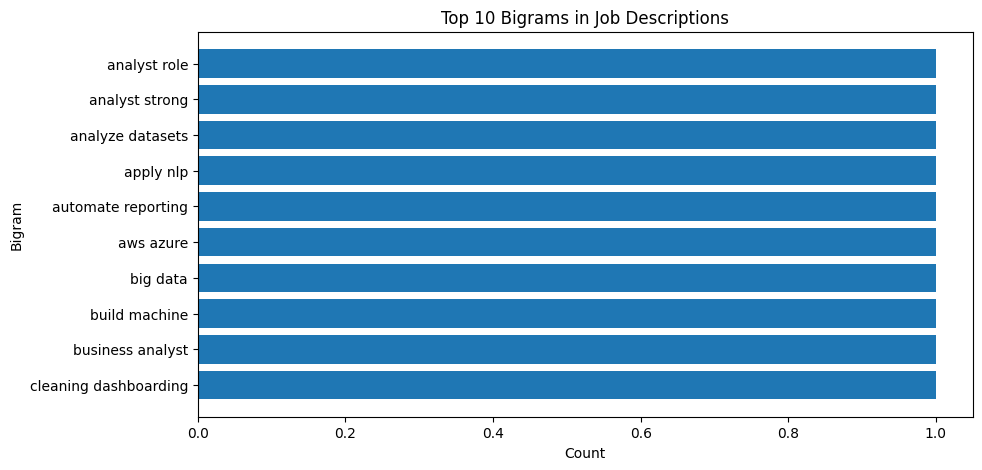

In [24]:
top_bigrams = bigram_freq_sorted[:10]
bigram_terms = [b[0] for b in top_bigrams]
bigram_vals = [b[1] for b in top_bigrams]

plt.figure(figsize=(10,5))
plt.barh(bigram_terms[::-1], bigram_vals[::-1])
plt.title("Top 10 Bigrams in Job Descriptions")
plt.xlabel("Count")
plt.ylabel("Bigram")
plt.show()


In [25]:
from sklearn.feature_extraction.text import CountVectorizer

# Use unigrams + bigrams for topic modeling
cv = CountVectorizer(
    max_df=0.9,
    min_df=1,
    ngram_range=(1, 2),
    max_features=100
)

X_cv = cv.fit_transform(df["clean_description"])
cv_features = np.array(cv.get_feature_names_out())

X_cv.shape


(6, 100)

In [26]:
from sklearn.decomposition import LatentDirichletAllocation

n_topics = 3  # choose 3 topics for demo
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda.fit(X_cv)


LatentDirichletAllocation(n_components=3, random_state=42)

In [27]:
def display_topics(model, feature_names, no_top_words=8):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\n===== Topic {topic_idx+1} =====")
        top_indices = topic.argsort()[::-1][:no_top_words]
        top_features = [feature_names[i] for i in top_indices]
        print(", ".join(top_features))

display_topics(lda, cv_features, no_top_words=8)



===== Topic 1 =====
strong, sql, analyst, nlp, model, nlp text, perform, model perform

===== Topic 2 =====
data, python, excel, platform, model nlp, ml model, nlp technique, experience

===== Topic 3 =====
model, ml, pytorch mlops, pytorch, ml engineer, model deployment, mlops, mlops kubernetes


In [28]:
topic_distributions = lda.transform(X_cv)   # shape: (n_docs, n_topics)

df["dominant_topic"] = topic_distributions.argmax(axis=1) + 1  # +1 to make topics 1-based

df[["job_title", "role_group", "dominant_topic"]]


,job_title,role_group,dominant_topic
0,Data Analyst,Data Analyst,2
1,Data Scientist,Data Scientist,2
2,Machine Learning Engineer,ML Engineer,3
3,Business Analyst,Business Analyst,1
4,Data Analyst,Data Analyst,2
5,Data Scientist,Data Scientist,1
